In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [71]:
df = pd.read_csv('UCI_Credit_Card.csv')

df['UTILIZATION_RATIO'] = df['BILL_AMT1'] / df['LIMIT_BAL']
df.replace([np.inf, -np.inf], 0, inplace=True)
df['PAY_TO_BILL_RATIO'] = df['PAY_AMT1'] / (df['BILL_AMT2'] + 1e-6)
df['PAY_TO_BILL_RATIO'] = df['PAY_TO_BILL_RATIO'].clip(lower=0, upper=2)
print(f"Dataset shape after feature engineering: {df.shape}")
df.head()
print(df['default.payment.next.month'].value_counts(normalize=True))

Dataset shape after feature engineering: (30000, 27)
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [72]:
X = df.drop(columns=['default.payment.next.month', 'ID'])
y = df['default.payment.next.month']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [74]:


custom_weights = {0: 1, 1: 2} 

rf_model = RandomForestClassifier(
    n_estimators=150, 
    class_weight=custom_weights,
    max_depth=10,               
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)
y_pred = rf_model.predict(X_test_scaled) 





Classification Report at 50% Threshold:
               precision    recall  f1-score   support

           0       0.90      0.59      0.71      4673
           1       0.35      0.77      0.48      1327

    accuracy                           0.63      6000
   macro avg       0.62      0.68      0.59      6000
weighted avg       0.78      0.63      0.66      6000



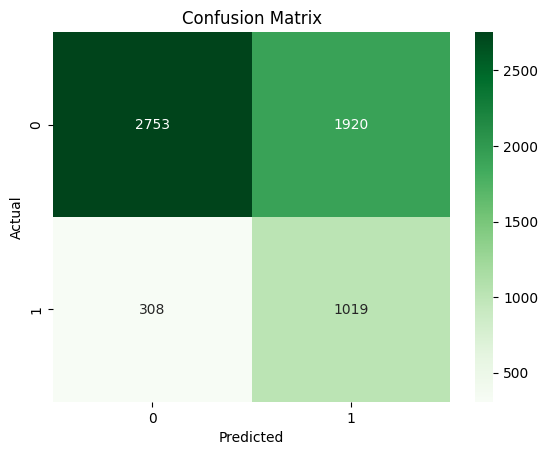

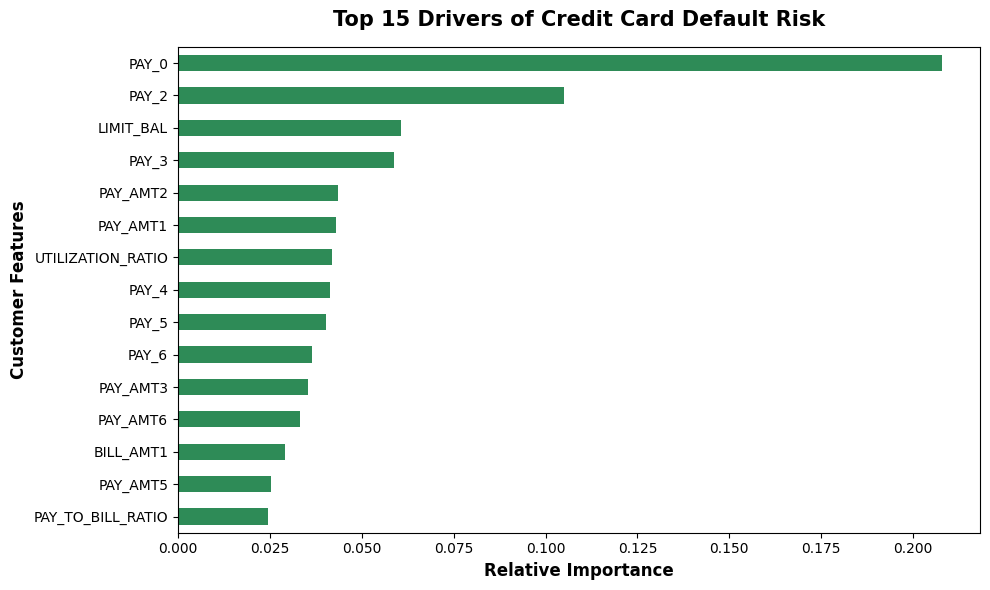

In [75]:
print("Classification Report at 50% Threshold:\n", classification_report(y_test, y_pred))

#  confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


# feature importances of model

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='seagreen') # Using green to match your matrix!
plt.xlabel('Relative Importance', fontsize=12, fontweight='bold')
plt.ylabel('Customer Features', fontsize=12, fontweight='bold')
plt.title('Top 15 Drivers of Credit Card Default Risk', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()